# Thesis 2024 - 2025
## UGBS
### Isil Oral

* Project on green gentrification in Vienna through social status index, green spaces, blue areas, and housing prices 

## Part 4 - Regression/Analysis

In [1]:
from shapely.geometry import box, Point, LineString, Polygon, MultiPolygon
from shapely.ops import unary_union
import geopandas as gpd
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject
from rasterio.enums import Resampling
import osmnx as ox  
import contextily as ctx
from geopy.geocoders import Nominatim  
from geopy.extra.rate_limiter import RateLimiter
import os
#!pip install h3
import h3
import matplotlib.patches as mpatches
import seaborn as sns
#!pip install scipy
from scipy.stats import skew
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

In [2]:
# Get the current working directory
current_path = os.getcwd()

# Define relative paths for data, output, and helper functions
data_in = os.path.join(current_path, "data")       # Folder with input data
output = os.path.join(current_path, "output")      # Folder for saving results
df_dir = os.path.join(current_path, "dataframes")

In [3]:
# Load any dataframe from that folder
admin_city = gpd.read_file(os.path.join(df_dir, "admin_city_vienna.geojson"))
urban_green_spaces =gpd.read_file(os.path.join(df_dir, "urban_green_spaces.geojson"))
urban_blue_spaces = gpd.read_file(os.path.join(df_dir, "urban_blue_spaces.geojson"))
ugbs_socioecon_census = gpd.read_file(os.path.join(df_dir, "ugbs_socioecon_census_final.geojson"))
socioecon_districts = gpd.read_file(os.path.join(df_dir, "socioecon_districts.geojson"))
housingprices_district = gpd.read_file(os.path.join(df_dir, "housingprices_district.geojson"))
social_housing = pd.read_csv(os.path.join(df_dir, "social_housing.csv"))
social_housing_gdf = gpd.read_file(os.path.join(df_dir, "social_housing.geojson"))
aptfeatures_social_census = pd.read_csv(os.path.join(df_dir, "aptfeatures_social_census.csv"))
apt_features_final_census = pd.read_csv(os.path.join(df_dir, "apt_features_final_census.csv"))
airbnb_entireunits_gdf = gpd.read_file(os.path.join(df_dir, "airbnb_entireunits.geojson"))

Skipping field ways: unsupported OGR type: 1
Skipping field amenities: unsupported OGR type: 5


### Remembering all (geo)dataframes

In [4]:
urban_green_spaces.head(3)

,id,F_TYP,T_TEXT,original_greenarea,area_m2,geometry
0,OEFFGRUENFLOGD.2289,L,Währinger Park,57020.131903,57020.220876,"MULTIPOLYGON (((1388.829 343923.309, 1274.719 ..."
1,OEFFGRUENFLOGD.2290,L,Türkenschanzplatz,2002.715993,2002.715999,"POLYGON ((-242.971 344049.152, -288.821 344059..."
2,OEFFGRUENFLOGD.2291,L,Kongreßpark/Kainzga,3243.484789,3243.484798,"POLYGON ((-1740.791 342714.09, -1694.181 34271..."


In [5]:
urban_blue_spaces.head(3)

,source,created_by,odbl,river:waterway_distance,waterway,seamark:type,name,maxwidth,obstacle,seamark:name,...,year_of_construction,toilets:wheelchair,memorial,fence_type,abandoned,lit,attraction,name:sh,species:wikidata,geometry
0,None,None,None,None,None,None,None,NaN,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((18220.629 334014.735, 18219.861 3340..."
1,None,None,None,None,None,None,None,NaN,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((17462.506 333997.675, 17470.506 3339..."
2,None,None,None,None,None,None,None,NaN,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((14616.91 335143.58, 14667.745 335160..."


In [6]:
print(len(ugbs_socioecon_census))
ugbs_socioecon_census.head(3)

246


,ZBEZ,census_boundaries_area,new_green_area,green_ratio,blue_new_area,blue_ratio,university_share,avg_income,employment,benefit_share,SSI,quintile,area_ssi,geometry
0,0101,377461.659643,1177.028363,0.003118,16.971625,0.000045,1.604954,1.741399,1.125923,1.123008,1.653992,5.0,377557.211380,"POLYGON ((3485.019 341498.126, 3484.459 341498..."
1,0102,379376.751348,77665.401597,0.204718,56987.074366,0.150212,1.653812,2.565233,1.237000,1.139440,2.000434,5.0,379376.751386,"POLYGON ((3487.789 341009.066, 3470.019 341017..."
2,0103,465496.860336,25072.878241,0.053863,20253.261827,0.043509,1.706598,3.805033,1.641029,1.232519,2.570582,5.0,465496.860383,"POLYGON ((2735.149 340257.116, 2743.919 340257..."


In [7]:
socioecon_districts.head(3)

,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,...,area,circumference,AKT_TIMEST,SE_SDO_ROW,district_avgincome,district_employment,district_univshare,district_benefitshare,district_SSI,geometry
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,...,3.771397e+07,29668.16,2023-07-18,13126.0,0.642256,0.369003,0.549082,0.285477,0.561803,"POLYGON ((-8763.201 340909.446, -8762.391 3409..."
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,...,3.916953e+06,9711.71,2023-07-18,13127.0,-0.624444,-0.296566,0.141626,-0.112714,-0.254327,"POLYGON ((-357.525 340733.412, 113.603 340627...."
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,...,1.608248e+06,5312.54,2023-07-18,13128.0,0.409909,0.407823,1.101009,0.588805,0.743321,"POLYGON ((489.859 341126.146, 511.359 341120.7..."


In [8]:
housingprices_district.head(3)

,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,...,2016,2017,2018,2019,2020,2021,2022,2023,avg_price_years,geometry
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,...,4132,4043,4423,4462,4821,5593,6159,5327,4799.11,"POLYGON ((-8763.201 340909.446, -8762.391 3409..."
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,...,3369,3315,3827,3860,4111,4729,4460,4215,3812.78,"POLYGON ((-357.525 340733.412, 113.603 340627...."
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,...,4553,4755,5405,5833,6043,6332,6336,5929,5551.11,"POLYGON ((489.859 341126.146, 511.359 341120.7..."


In [9]:
apt_features_final_census.head(3)

,district_code,census_district_code,total_apartments,no_central_heating,central_heating,owner_private,owner_public,owner_nonprofit,owner_other
0,90100,90101,2686,94,2592,1271,483,4,928
1,90100,90102,945,31,914,559,33,4,349
2,90100,90103,1294,34,1260,708,74,0,512


In [10]:
social_housing.head(3)

,Hofname,clean_address,Wohnungen,Lokale
0,Per-Albin-Hansson-Siedlung-Ost,"1100 Wien, Jura-Soyfer-Gasse",4289,25
1,Rudolf-Hitzinger-Hof,"1210 Wien, Leopoldauer Straße",284,7
2,Großfeldsiedlung,"1210 Wien, St.-Michael-Gasse",5525,41


In [11]:
social_housing_gdf.head(3)

,Hofname,clean_address,Wohnungen,Lokale,addr_key,geometry
0,Per-Albin-Hansson-Siedlung-Ost,"1100 Wien, Jura-Soyfer-Gasse",4289,25,"1100 wien, jura-soyfer-gasse",POINT (16.39202 48.14767)
1,Rudolf-Hitzinger-Hof,"1210 Wien, Leopoldauer Straße",284,7,"1210 wien, leopoldauer straße",POINT (16.40495 48.25741)
2,Großfeldsiedlung,"1210 Wien, St.-Michael-Gasse",5525,41,"1210 wien, st.-michael-gasse",POINT (16.43977 48.26674)


In [12]:
aptfeatures_social_census['census_district_code'].dtype

dtype('int64')

In [13]:
aptfeatures_social_census['census_district_code'] = (
    aptfeatures_social_census['census_district_code']
    .apply(lambda x: str(x).zfill(4))
)

In [14]:
aptfeatures_social_census['census_district_code'].dtype

dtype('O')

In [15]:
aptfeatures_social_census.head(3)
print(len(aptfeatures_social_census))

249


### Creation of the one necessary dataframe
* This data frame includes for every census district (250)
    * census district code
  * socioeconomic variables (avg_income, SSI mainly)
  * green ratio
  * blue ratio
  * apartment features (type of ownership, heating type)
  * how many social housing exists in that census district
  * social housing rate

* This dataframe is created by using ugbs_socioecon_census & aptfeatures_social_census

* It's name is 'merged_census'

In [16]:
print(len(ugbs_socioecon_census))
print(len(aptfeatures_social_census))

246
249


In [17]:
boundaries_path = 'data/ZAEHLBEZIRKOGDPolygon.shp'
census_boundaries = gpd.read_file(boundaries_path)
print(len(census_boundaries))

250


In [18]:
merged_census = ugbs_socioecon_census.merge(
    aptfeatures_social_census, 
    left_on='ZBEZ', 
    right_on='census_district_code', 
    how='outer'
)

# Convert back to GeoDataFrame, using the original geometry
merged_census = gpd.GeoDataFrame(merged_census, geometry='geometry')
# Set the correct CRS (copied from ugbs_socioecon_census)
merged_census.set_crs(ugbs_socioecon_census.crs, inplace=True)

print(merged_census.columns.to_list())
print(len(merged_census))
print(type(merged_census))

['ZBEZ', 'census_boundaries_area', 'new_green_area', 'green_ratio', 'blue_new_area', 'blue_ratio', 'university_share', 'avg_income', 'employment', 'benefit_share', 'SSI', 'quintile', 'area_ssi', 'geometry', 'district_code', 'census_district_code', 'total_apartments', 'no_central_heating', 'central_heating', 'owner_private', 'owner_public', 'owner_nonprofit', 'owner_other', 'social_housing_units', 'social_housing_ratio']
249
<class 'geopandas.geodataframe.GeoDataFrame'>


In [19]:
merged_census.drop(['census_district_code'], axis=1, inplace=True)

In [20]:
print(merged_census.columns.to_list())
merged_census.rename(columns={'district_code': 'BEZ'}, inplace=True)

merged_census = merged_census.dropna(subset=['avg_income', 'employment'])

print(len(merged_census))
merged_census.head(3)

['ZBEZ', 'census_boundaries_area', 'new_green_area', 'green_ratio', 'blue_new_area', 'blue_ratio', 'university_share', 'avg_income', 'employment', 'benefit_share', 'SSI', 'quintile', 'area_ssi', 'geometry', 'district_code', 'total_apartments', 'no_central_heating', 'central_heating', 'owner_private', 'owner_public', 'owner_nonprofit', 'owner_other', 'social_housing_units', 'social_housing_ratio']
246


,ZBEZ,census_boundaries_area,new_green_area,green_ratio,blue_new_area,blue_ratio,university_share,avg_income,employment,benefit_share,...,BEZ,total_apartments,no_central_heating,central_heating,owner_private,owner_public,owner_nonprofit,owner_other,social_housing_units,social_housing_ratio
0,0101,377461.659643,1177.028363,0.003118,16.971625,0.000045,1.604954,1.741399,1.125923,1.123008,...,90100,2686,94,2592,1271,483,4,928,18.0,0.0067
1,0102,379376.751348,77665.401597,0.204718,56987.074366,0.150212,1.653812,2.565233,1.237000,1.139440,...,90100,945,31,914,559,33,4,349,54.0,0.0571
2,0103,465496.860336,25072.878241,0.053863,20253.261827,0.043509,1.706598,3.805033,1.641029,1.232519,...,90100,1294,34,1260,708,74,0,512,0.0,0.0000


In [21]:
merged_census['centralheating_rate'] = merged_census['central_heating'] / merged_census['total_apartments']
merged_census['private_ownership_rate'] = merged_census['owner_private'] / merged_census['total_apartments']
print(merged_census.columns.to_list())
merged_census.head(3)

['ZBEZ', 'census_boundaries_area', 'new_green_area', 'green_ratio', 'blue_new_area', 'blue_ratio', 'university_share', 'avg_income', 'employment', 'benefit_share', 'SSI', 'quintile', 'area_ssi', 'geometry', 'BEZ', 'total_apartments', 'no_central_heating', 'central_heating', 'owner_private', 'owner_public', 'owner_nonprofit', 'owner_other', 'social_housing_units', 'social_housing_ratio', 'centralheating_rate', 'private_ownership_rate']


,ZBEZ,census_boundaries_area,new_green_area,green_ratio,blue_new_area,blue_ratio,university_share,avg_income,employment,benefit_share,...,no_central_heating,central_heating,owner_private,owner_public,owner_nonprofit,owner_other,social_housing_units,social_housing_ratio,centralheating_rate,private_ownership_rate
0,0101,377461.659643,1177.028363,0.003118,16.971625,0.000045,1.604954,1.741399,1.125923,1.123008,...,94,2592,1271,483,4,928,18.0,0.0067,0.965004,0.473194
1,0102,379376.751348,77665.401597,0.204718,56987.074366,0.150212,1.653812,2.565233,1.237000,1.139440,...,31,914,559,33,4,349,54.0,0.0571,0.967196,0.591534
2,0103,465496.860336,25072.878241,0.053863,20253.261827,0.043509,1.706598,3.805033,1.641029,1.232519,...,34,1260,708,74,0,512,0.0,0.0000,0.973725,0.547141


In [22]:
print(type(merged_census))
merged_census.to_file("dataframes/merged_census.geojson", driver="GeoJSON")

<class 'geopandas.geodataframe.GeoDataFrame'>


### Correlation check
* average income per district and apartment prices per sq meter per district
* if they are correlated highly, I can use average income per census district as a proxy for apartment prices per census district per sq meter
* I will use the following 2 dataframes
    * socioecon_district
    * housingprices_district

In [23]:
print(socioecon_districts.columns.to_list())
print(housingprices_district.columns.to_list())

['NAMEK', 'BEZNR', 'BEZ_RZ', 'NAMEK_NUM', 'NAMEK_RZ', 'NAMEG', 'LABEL', 'BEZ', 'DISTRICT_C', 'STATAUSTRI', 'STATAUSTR0', 'area', 'circumference', 'AKT_TIMEST', 'SE_SDO_ROW', 'district_avgincome', 'district_employment', 'district_univshare', 'district_benefitshare', 'district_SSI', 'geometry']
['NAMEK', 'BEZNR', 'BEZ_RZ', 'NAMEK_NUM', 'NAMEK_RZ', 'NAMEG', 'LABEL', 'BEZ', 'DISTRICT_C', 'STATAUSTRI', 'STATAUSTR0', 'area', 'circumference', 'AKT_TIMEST', 'SE_SDO_ROW', 'district_clean', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', 'avg_price_years', 'geometry']


In [24]:
# Correlation matrix
avginc_price_corr = pd.DataFrame({
    'BEZ': socioecon_districts['BEZ'],
    'avg_income': socioecon_districts['district_avgincome'],
    'employment':socioecon_districts['district_employment'],
    'univ_share':socioecon_districts['district_univshare'],
    'benefit_share':socioecon_districts['district_benefitshare'],
    'district_SSI':socioecon_districts['district_SSI'],
    'avg_price': housingprices_district['avg_price_years']
})

In [25]:
print("Min:", avginc_price_corr["avg_income"].min())
print("Max:", avginc_price_corr["avg_income"].max())
print("Mean:", avginc_price_corr["avg_income"].mean())
print("Median:", avginc_price_corr["avg_income"].median())

Min: -0.6244442680973263
Max: 1.3904667246978366
Mean: 0.1703871882559156
Median: 0.2007852089440684


In [26]:
min_inc_row = avginc_price_corr.loc[avginc_price_corr["avg_income"].idxmin()]
max_inc_row = avginc_price_corr.loc[avginc_price_corr["avg_income"].idxmax()]

print("\nDistrict with MIN Average Income:")
print(min_inc_row[["BEZ", "avg_income", "district_SSI", "avg_price"]])

print("\nDistrict with MAX Average Income:")
print(max_inc_row[["BEZ", "avg_income", "district_SSI", "avg_price"]])

## District 1 (i.e. Innere Stadt is an outlier)
## exclude Innere Stadt while looking for correlation


District with MIN Average Income:
BEZ                   15
avg_income     -0.624444
district_SSI   -0.254327
avg_price        3812.78
Name: 1, dtype: object

District with MAX Average Income:
BEZ                   01
avg_income      1.390467
district_SSI    1.456749
avg_price       10787.33
Name: 5, dtype: object


In [27]:
# Compute correlation all 23 district
income_price_corr = avginc_price_corr.corr().loc['avg_income', 'avg_price']
ssi_price_corr = avginc_price_corr.corr().loc['district_SSI', 'avg_price']
print("Correlation (avg_income vs avg_price):", income_price_corr.round(3))
print("Correlation (district_SSI vs avg_price):", ssi_price_corr.round(3))

with open("output/income_price_corr_summary.txt", "w") as f:
    f.write(f"Correlation (avg_income vs avg_price): {income_price_corr.round(3)}\n")
    f.write(f"Correlation (district_SSI vs avg_price): {ssi_price_corr.round(3)}\n")

Correlation (avg_income vs avg_price): 0.781
Correlation (district_SSI vs avg_price): 0.768


In [28]:
# Correlation of districts (excluding Innere Stadt, i.e. BEZ==01)
filtered_df = avginc_price_corr[avginc_price_corr['BEZ'] != '01']

# Compute correlations
income_price_corr_filtered = filtered_df.corr().loc['avg_income', 'avg_price']
ssi_price_corr_filtered = filtered_df.corr().loc['district_SSI', 'avg_price']

# Print results
print(len(filtered_df))
print("Correlation excluding Innere Stadt (avg_income vs avg_price):", income_price_corr_filtered.round(3))
print("Correlation excluding Innere Stadt (district_SSI vs avg_price):", income_price_corr_filtered.round(3))

with open("output/income_price_corr_excInnereStadt_summary.txt", "w") as f:
    f.write(f"Number of districts (excluding Innere Stadt): {len(filtered_df)}\n")
    f.write(f"Correlation excluding Innere Stadt (avg_income vs avg_price): {income_price_corr_filtered.round(3)}\n")
    f.write(f"Correlation excluding Innere Stadt (district_SSI vs avg_price): {ssi_price_corr_filtered.round(3)}\n")

22
Correlation excluding Innere Stadt (avg_income vs avg_price): 0.833
Correlation excluding Innere Stadt (district_SSI vs avg_price): 0.833


In [29]:
# Step 1: Select only relevant columns
plot_df = avginc_price_corr[['avg_income', 'district_SSI', 'avg_price']].copy()
plot_df_filtered = filtered_df[['avg_income', 'district_SSI', 'avg_price']].copy()

# Step 2: Convert all to numeric (in case something was parsed as object)
plot_df = plot_df.apply(pd.to_numeric, errors='coerce')
plot_df_filtered = plot_df_filtered.apply(pd.to_numeric, errors='coerce')

# Step 3: Drop any rows with NaNs
plot_df = plot_df.dropna()
plot_df_filtered = plot_df_filtered.dropna()

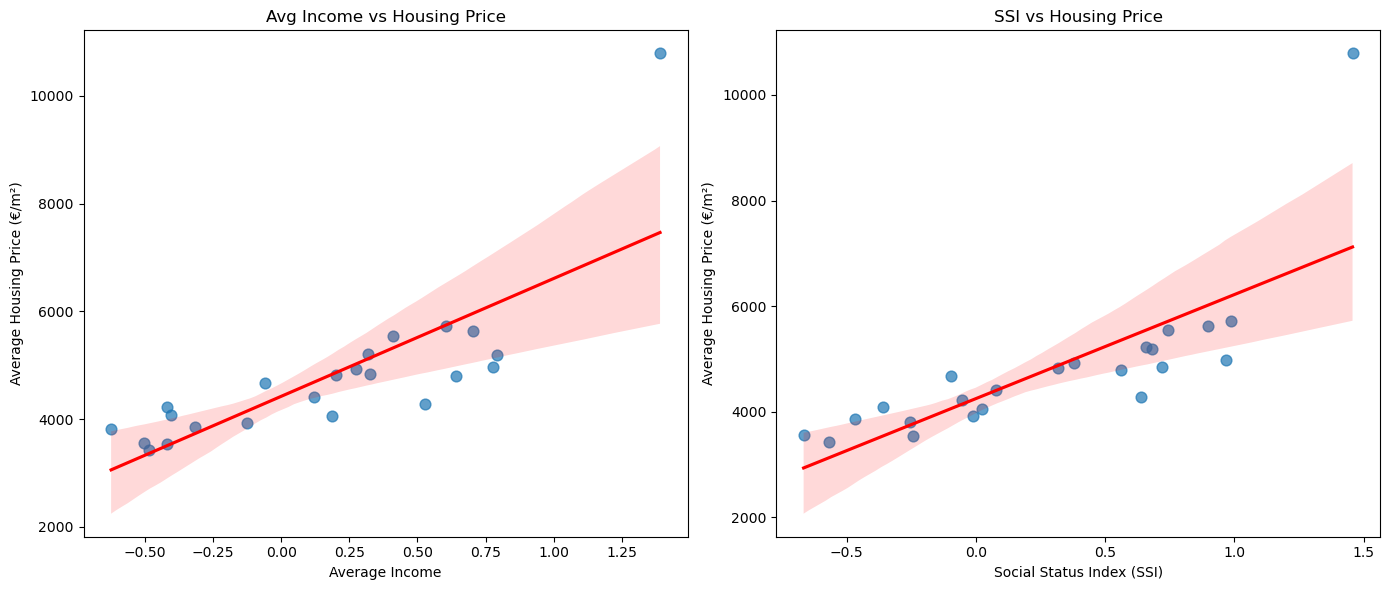

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# avg_income vs avg_price
sns.regplot(
    data=plot_df,
    x='avg_income',
    y='avg_price',
    ax=axes[0],
    scatter_kws={'s': 60, 'alpha': 0.7},
    line_kws={'color': 'red'}
)
axes[0].set_title('Avg Income vs Housing Price')
axes[0].set_xlabel('Average Income')
axes[0].set_ylabel('Average Housing Price (€/m²)')

# district_SSI vs avg_price
sns.regplot(
    data=plot_df,
    x='district_SSI',
    y='avg_price',
    ax=axes[1],
    scatter_kws={'s': 60, 'alpha': 0.7},
    line_kws={'color': 'red'}
)
axes[1].set_title('SSI vs Housing Price')
axes[1].set_xlabel('Social Status Index (SSI)')
axes[1].set_ylabel('Average Housing Price (€/m²)')

plt.tight_layout()
plt.savefig("output/04Analysis/income_price_ssi_corr.png", dpi=300, bbox_inches='tight')
plt.show()

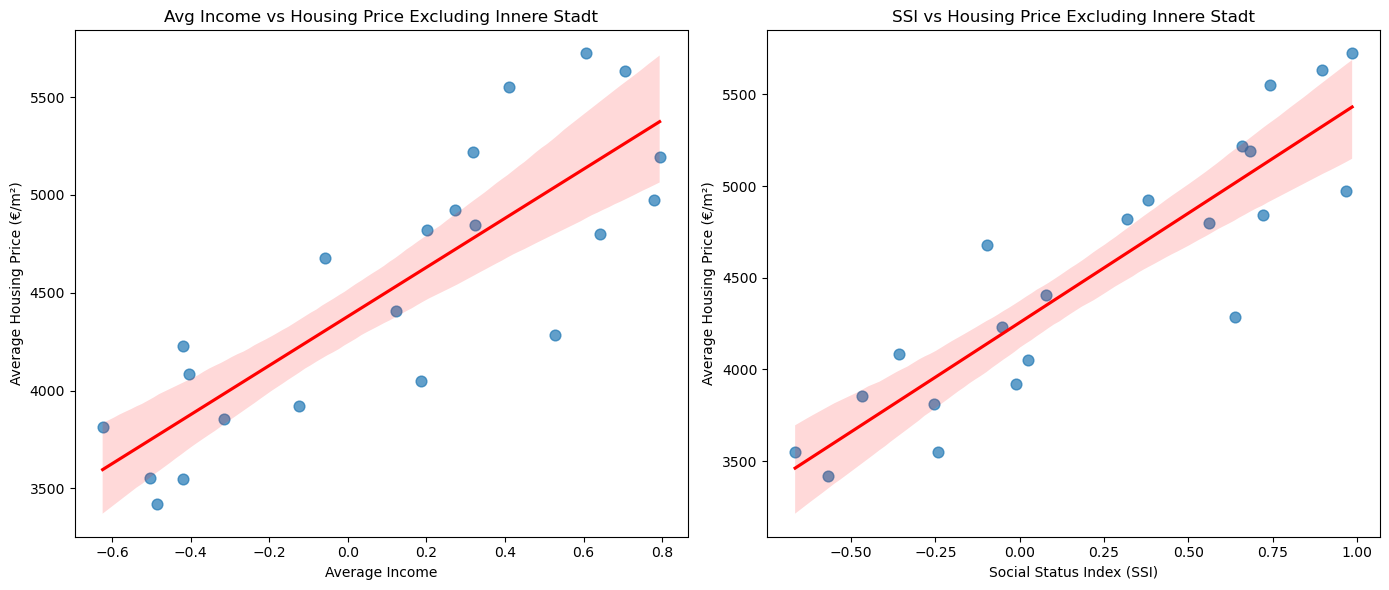

In [31]:
# Correlation excluding Innere Stadt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# avg_income vs avg_price
sns.regplot(
    data=plot_df_filtered,
    x='avg_income',
    y='avg_price',
    ax=axes[0],
    scatter_kws={'s': 60, 'alpha': 0.7},
    line_kws={'color': 'red'}
)
axes[0].set_title('Avg Income vs Housing Price Excluding Innere Stadt')
axes[0].set_xlabel('Average Income')
axes[0].set_ylabel('Average Housing Price (€/m²)')

# district_SSI vs avg_price
sns.regplot(
    data=plot_df_filtered,
    x='district_SSI',
    y='avg_price',
    ax=axes[1],
    scatter_kws={'s': 60, 'alpha': 0.7},
    line_kws={'color': 'red'}
)
axes[1].set_title('SSI vs Housing Price Excluding Innere Stadt')
axes[1].set_xlabel('Social Status Index (SSI)')
axes[1].set_ylabel('Average Housing Price (€/m²)')

plt.tight_layout()
plt.savefig("output/04Analysis/income_price_ssi_corr_filtered.png", dpi=300, bbox_inches='tight')
plt.show()

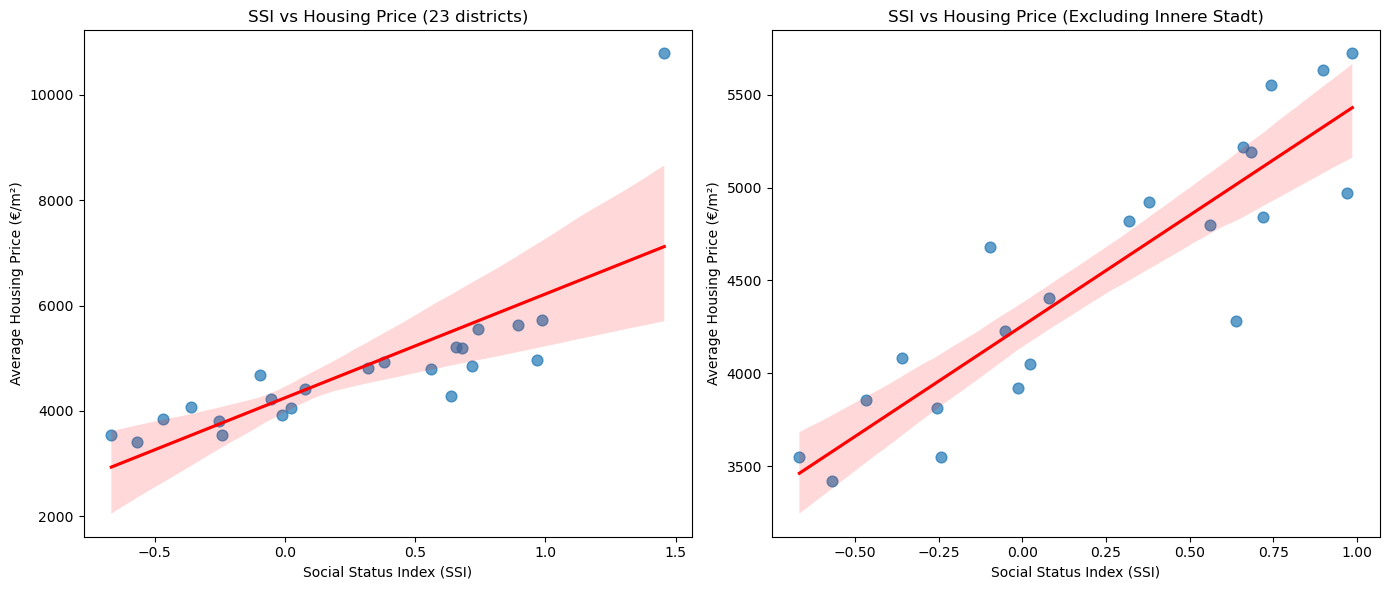

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# SSI vs avg_price (INCLUDING INNERE STADT)
sns.regplot(
    data=plot_df,
    x='district_SSI',
    y='avg_price',
    ax=axes[0],
    scatter_kws={'s': 60, 'alpha': 0.7},
    line_kws={'color': 'red'}
)
axes[0].set_title('SSI vs Housing Price (23 districts)')
axes[0].set_xlabel('Social Status Index (SSI)')
axes[0].set_ylabel('Average Housing Price (€/m²)')

# SSI vs avg_price (EXCLUDING INNERE STADT)
sns.regplot(
    data=plot_df_filtered,
    x='district_SSI',
    y='avg_price',
    ax=axes[1],
    scatter_kws={'s': 60, 'alpha': 0.7},
    line_kws={'color': 'red'}
)
axes[1].set_title('SSI vs Housing Price (Excluding Innere Stadt)')
axes[1].set_xlabel('Social Status Index (SSI)')
axes[1].set_ylabel('Average Housing Price (€/m²)')

plt.tight_layout()
plt.savefig("output/04Analysis/ssi_price_corr_both.png", dpi=300, bbox_inches='tight')
plt.show()

### OLS

In [33]:
print(len(merged_census))
merged_census.columns.to_list()

246


['ZBEZ',
 'census_boundaries_area',
 'new_green_area',
 'green_ratio',
 'blue_new_area',
 'blue_ratio',
 'university_share',
 'avg_income',
 'employment',
 'benefit_share',
 'SSI',
 'quintile',
 'area_ssi',
 'geometry',
 'BEZ',
 'total_apartments',
 'no_central_heating',
 'central_heating',
 'owner_private',
 'owner_public',
 'owner_nonprofit',
 'owner_other',
 'social_housing_units',
 'social_housing_ratio',
 'centralheating_rate',
 'private_ownership_rate']

In [34]:
# check for any NaNs
print(merged_census['green_ratio'].isna().any())
print(merged_census['green_ratio'].isna().sum())
print(merged_census['blue_ratio'].isna().any())
print(merged_census['blue_ratio'].isna().sum())
print(merged_census['social_housing_ratio'].isna().any())
print(merged_census['centralheating_rate'].isna().any())
print(merged_census['private_ownership_rate'].isna().any())

False
0
False
0
False
False
False


In [35]:
print(merged_census['BEZ'].dtype)

int64


In [36]:
merged_census_filtered = merged_census[merged_census['BEZ'] != 90100]
print(len(merged_census_filtered)) 
# 7 census districts that are in Innere Stadt are filtered

239


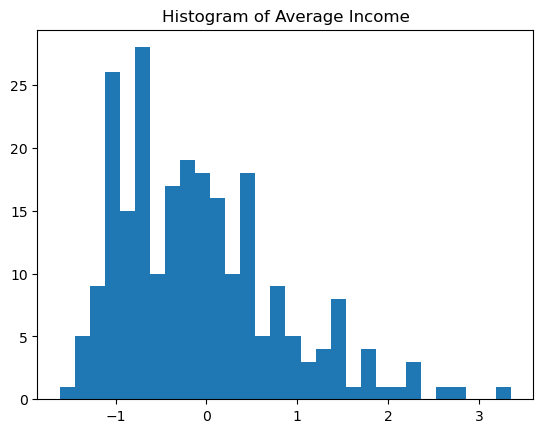

In [37]:
plt.hist(merged_census_filtered['avg_income'], bins=30)
plt.title('Histogram of Average Income')
plt.show()

In [38]:
skewness = skew(merged_census_filtered['avg_income'].dropna())
print("Skewness:", skewness.round(3))

Skewness: 0.973


In [39]:
# MODEL 1 - 23 DISTRICTS & NONROBUST-ROBUST
# Define dependent variable (Y): Average Income of each census district
Y = merged_census['avg_income']  

# Define your independent variables (X)
X_ugbs = merged_census[['green_ratio', 'blue_ratio']]

X = merged_census[['green_ratio', 'blue_ratio', 
                   'social_housing_ratio']]

X_apt = merged_census[['green_ratio', 'blue_ratio', 
                   'social_housing_ratio', 
                   'centralheating_rate', 'private_ownership_rate']]

X_soc = merged_census[['employment', 'university_share', 'benefit_share']]

X_all = merged_census[['green_ratio', 'blue_ratio', 
                   'social_housing_ratio', 
                   'centralheating_rate', 
                   'employment', 'university_share', 'benefit_share',
                             'private_ownership_rate']]

# Add constant for intercept
X_ugbs = sm.add_constant(X_ugbs)
X = sm.add_constant(X)
X_apt = sm.add_constant(X_apt)
X_soc = sm.add_constant(X_soc)
X_all = sm.add_constant(X_all)

# Fit the model
income_all_notrobust = sm.OLS(Y,X_all).fit()
income_ugbs = sm.OLS(Y, X_ugbs).fit(cov_type='HC1')
income2 = sm.OLS(Y, X).fit(cov_type='HC1')
income_apt = sm.OLS(Y, X_apt).fit(cov_type='HC1')
income_soc = sm.OLS(Y, X_soc).fit(cov_type='HC1')
income_all = sm.OLS(Y,X_all).fit(cov_type='HC1')
    
# Print the summary
# print(summary_col([income_all_notrobust], stars=True))
# print(summary_col([income_ugbs], stars=True))
# print(summary_col([income2], stars=True))
# print(summary_col([income_apt], stars=True))
# print(summary_col([income_soc], stars=True))
# print(summary_col([income_all], stars=True))

In [40]:
# Save merged_census model results as .txt with explanatory titles
census_model_results = {
    "AllVars_NotRobust_23": income_all_notrobust,
    "UGBS_Only_23": income_ugbs,
    "UGBS_SocHousing_23": income2,
    "UGBS_SocHousing_Apt_23": income_apt,
    "SocEcon_Variables_Only_23": income_soc,
    "AllVars_Robust_23": income_all,
}

for name, model in census_model_results.items():
    with open(f"output/04Analysis/census_{name}.txt", "w") as f:
        f.write(f"Model: {name}\n\n")
        f.write(model.summary().as_text())
        f.write("\n\n== Summary (Significance Stars) ==\n")
        f.write(summary_col([model], stars=True, model_names=[name]).as_text())

In [41]:
# MODEL 2.2.1 - EXCLUDING INNERE STADT and NAs & ROBUST
# Define dependent variable (Y): Average Income of each census district
Y = merged_census_filtered['avg_income']  

# Define your independent variables (X)
X_ugbs = merged_census_filtered[['green_ratio', 'blue_ratio']]

X = merged_census_filtered[['green_ratio', 'blue_ratio', 
                   'social_housing_ratio']]

X_apt = merged_census_filtered[['green_ratio', 'blue_ratio', 
                   'social_housing_ratio', 
                   'centralheating_rate', 'private_ownership_rate']]

X_soc = merged_census_filtered[['employment', 'university_share', 'benefit_share']]

X_all = merged_census_filtered[['green_ratio', 'blue_ratio', 
                   'social_housing_ratio', 
                   'centralheating_rate', 
                   'employment', 'university_share', 'benefit_share',
                             'private_ownership_rate']]

# Add constant for intercept
X_ugbs = sm.add_constant(X_ugbs)
X = sm.add_constant(X)
X_apt = sm.add_constant(X_apt)
X_soc = sm.add_constant(X_soc)
X_all = sm.add_constant(X_all)

# Fit the model
income_ugbs = sm.OLS(Y, X_ugbs).fit(cov_type='HC1')
income2 = sm.OLS(Y, X).fit(cov_type='HC1')
income_apt = sm.OLS(Y, X_apt).fit(cov_type='HC1')
income_soc = sm.OLS(Y, X_soc).fit(cov_type='HC1')
income_all = sm.OLS(Y,X_all).fit(cov_type='HC1')
    
# Print the summary
# print(summary_col([income_ugbs], stars=True))
# print(summary_col([income2], stars=True))
# print(summary_col([income_apt], stars=True))
# print(summary_col([income_soc], stars=True))
# print(summary_col([income_all], stars=True))

In [42]:
# Save merged_census_filtered model results as .txt with explanatory titles
census_filtered_model_results = {
    "UGBS_Only_22": income_ugbs,
    "UGBS_SocHousing_22": income2,
    "UGBS_SocHousing_Apt_22": income_apt,
    "Social_Variables_Only_22": income_soc,
    "AllVars_22": income_all,
}

# Save each model
for name, model in census_filtered_model_results.items():
    with open(f"output/04Analysis/census_{name}.txt", "w") as f:
        f.write(f"Model: {name} (filtered dataset, robust SEs)\n\n")
        f.write(model.summary().as_text())
        f.write("\n\n== Summary (Significance Stars) ==\n")
        f.write(summary_col([model], stars=True, model_names=[name]).as_text())

In [43]:
# MODEL 2.2.2 - EXCLUDING INNERE STADT and NAs & ROBUST
# Define dependent variable (Y): SSI of each census district
Y = merged_census_filtered['SSI']  

# Define your independent variables (X)
X_ugbs = merged_census_filtered[['green_ratio', 'blue_ratio']]

X = merged_census_filtered[['green_ratio', 'blue_ratio', 
                   'social_housing_ratio']]

X_apt = merged_census_filtered[['green_ratio', 'blue_ratio', 
                   'social_housing_ratio', 
                   'centralheating_rate', 'private_ownership_rate']]

X_soc = merged_census_filtered[['employment', 'university_share', 'benefit_share']]

X_all = merged_census_filtered[['green_ratio', 'blue_ratio', 
                   'social_housing_ratio', 
                   'centralheating_rate', 
                   'employment', 'university_share', 'benefit_share',
                             'private_ownership_rate']]

# Add constant for intercept
X_ugbs = sm.add_constant(X_ugbs)
X = sm.add_constant(X)
X_apt = sm.add_constant(X_apt)
X_soc = sm.add_constant(X_soc)
X_all = sm.add_constant(X_all)

# Fit the model
ssi_ugbs = sm.OLS(Y, X_ugbs).fit(cov_type='HC1')
ssi2 = sm.OLS(Y, X).fit(cov_type='HC1')
ssi_apt = sm.OLS(Y, X_apt).fit(cov_type='HC1')
ssi_soc = sm.OLS(Y, X_soc).fit(cov_type='HC1')
ssi_all = sm.OLS(Y,X_all).fit(cov_type='HC1')

# with open("output/ssi_ugbs_robust.txt", "w") as f:
#    f.write(ssi_ugbs_robust.summary().as_text())
    
# Print the summary
# print(ssi_ugbs.summary())
# print(summary_col([ssi_ugbs], stars=True))
# print(summary_col([ssi2], stars=True))
# print(summary_col([ssi_apt], stars=True))
# print(summary_col([ssi_soc], stars=True))
# print(summary_col([ssi_all], stars=True))

In [44]:
# Save SSI regression model results as .txt with explanatory titles
ssi_model_results = {
    "SSI_UGBS_Only_22": ssi_ugbs,
    "SSI_UGBS_SocHousing_22": ssi2,
    "SSI_UGBS_SocHousing_Apt_22": ssi_apt,
    "SSI_Social_Variables_Only_22": ssi_soc,
    "SSI_AllVars_22": ssi_all,
}

# Save each model
for name, model in ssi_model_results.items():
    with open(f"output/04Analysis/census_{name}.txt", "w") as f:
        f.write(f"Model: {name} (SSI as dependent variable, robust SEs)\n\n")
        f.write(model.summary().as_text())
        f.write("\n\n== Summary (Significance Stars) ==\n")
        f.write(summary_col([model], stars=True, model_names=[name]).as_text())